In [34]:
# Import libries
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt


current_directory = os.getcwd()
pd.set_option("display.max_columns", None)

print("Current Directory:", current_directory)

Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [2]:
#         .map{ row-> tuple(  row.aa_barcode,
#                             row.patient_barcode,
#                             row.project,
#                             row.tm_object_id,
#                             row.nm_object_id,
#                             row.cp_output_dir,
#                             row.action ) }

## aaSuite_germline_ss

In [36]:
manifest=pd.read_csv('../manifest/ECTRES_clones_nf_dna_fastqs_20260303.csv')
manifest["sample_id"] = manifest["sample_legacy_id"].fillna("parental")
sample_mapping = manifest[['aliquot_barcode','source_barcode','sample_barcode','patient_barcode','sample_id']].drop_duplicates()
sample_mapping.head()


,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id
0,ECTRES-ECGI1-0001-TPX-A01-WGS-6DM349,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,EG_1
2,ECTRES-ECGI1-0001-TPX-A10-WGS-3SW949,ECGI1,ECTRES-ECGI1-0001-TPX-A10,ECTRES-ECGI1-0001,EG_10
3,ECTRES-ECGI1-0001-TPX-A11-WGS-9HJ669,ECGI1,ECTRES-ECGI1-0001-TPX-A11,ECTRES-ECGI1-0001,EG_11
4,ECTRES-ECGI1-0001-TPX-A12-WGS-4SL389,ECGI1,ECTRES-ECGI1-0001-TPX-A12,ECTRES-ECGI1-0001,EG_12
5,ECTRES-ECGI1-0001-TPX-A13-WGS-3VZ640,ECGI1,ECTRES-ECGI1-0001-TPX-A13,ECTRES-ECGI1-0001,EG_13


In [47]:
sample_mapping[sample_mapping['sample_id']=='parental']

,aliquot_barcode,source_barcode,sample_barcode,patient_barcode,sample_id,aa_barcode,project,tm_object_id,nm_object_id,cp_output_dir,action
60,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,H2170,ECTRES-H2170-0001-TPX-A01,ECTRES-H2170-0001,parental,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,H2170,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,ECTRES-H2170-0001-TPX-A01-WGS-3YV111,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,run
61,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,ECGI1,ECTRES-ECGI1-0001-TPX-A01,ECTRES-ECGI1-0001,parental,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,ECGI1,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,ECTRES-ECGI1-0001-TPX-A01-WGS-1ST985,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,run
62,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,EFM19,ECTRES-EFM19-0001-TPX-A01,ECTRES-EFM19-0001,parental,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,EFM19,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,run


In [39]:
# /mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_germline_ms/v1.3.8/GRCh37/minCN4.5/cnsizeMin50000/1X/calls

sample_mapping['aa_barcode']=sample_mapping['aliquot_barcode']
sample_mapping['project']=sample_mapping['source_barcode']
sample_mapping['tm_object_id']=sample_mapping['aliquot_barcode']
sample_mapping['nm_object_id']=sample_mapping['aliquot_barcode']
sample_mapping['cp_output_dir']='/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_germline_ms/v1.3.8/GRCh37/minCN4.5/cnsizeMin50000/10X/calls/'+sample_mapping['aliquot_barcode']
sample_mapping['action']='run'

# sample_mapping.to_csv('../manifest/ECTRES_clones_nf_similarity.csv',index=False)

# AC_similarity_score

In [55]:
# base_dir = '/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_amplicon_similarity/v0.1344.2/GRCh37/minCN4.5/cnsizeMin50000/10X/aaSuite_amplicon_similarity/ECTRES-EFM19-0001/run_similarity/'

base_dir = '/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/results/aaSuite_amplicon_similarity/v0.1344.2/GRCh37/minCN4.5/cnsizeMin50000/10X/aaSuite_amplicon_similarity/ECTRES-EFM19-0001/run_similarity'


similarity = pd.read_csv(f'{base_dir}/ECTRES-EFM19-0001_amplicon_similarity_scores.tsv',sep='\t')

print(similarity.shape)
similarity.head(2)

(40, 19)


,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen
0,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.459488,97.532895,0.014376,0.675000,0.243976,0,0,0.900000,0.325301,0,0.313953,54.0,60,166,61688597,64967883,63299161
1,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.450032,97.532895,0.016227,0.669643,0.230422,0,0,0.892857,0.307229,0,0.290698,50.0,56,166,61370712,62658797,63299161


In [57]:
df=similarity.copy()
# ECTRES-EFM19-0001-TPX-A01-WGS-2PV977
df[(df['Amp1'].str.contains('ECTRES-EFM19-0001-TPX-A01-WGS-2PV977', na=False))|(df['Amp2'].str.contains('ECTRES-EFM19-0001-TPX-A01-WGS-2PV977', na=False))]


,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen
0,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.459488,97.532895,0.014376,0.675000,0.243976,0,0,0.900000,0.325301,0,0.313953,54.0,60,166,61688597,64967883,63299161
1,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.450032,97.532895,0.016227,0.669643,0.230422,0,0,0.892857,0.307229,0,0.290698,50.0,56,166,61370712,62658797,63299161
3,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.430674,97.039474,0.020658,0.725806,0.135542,0,0,0.967742,0.180723,0,0.179641,30.0,31,166,36393481,36516873,63299161
6,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.422870,96.875000,0.022716,0.678571,0.167169,0,0,0.904762,0.222892,0,0.223529,38.0,42,166,49646684,50629656,63299161
9,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K_amplicon6,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.403698,96.381579,0.028532,0.694444,0.112952,0,0,0.925926,0.150602,0,0.148810,25.0,27,166,46581973,48206469,63299161
11,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.391459,96.217105,0.032875,0.642857,0.140060,0,0,0.857143,0.186747,0,0.175439,30.0,35,166,47193611,48944364,63299161
13,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.385448,95.559211,0.035206,0.703125,0.067771,0,0,0.937500,0.090361,0,0.089820,15.0,16,166,13555837,13569260,63299161
14,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.383689,95.559211,0.035915,0.663462,0.103916,0,0,0.884615,0.138554,0,0.136095,23.0,26,166,36410634,37864454,63299161
15,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.371268,95.559211,0.041273,0.652174,0.090361,0,0,0.869565,0.120482,0,0.118343,20.0,23,166,36033362,37589348,63299161


In [67]:
df=similarity.copy()
# df['patient_barcode'] = df['file_name'].str.extract(r'^(.*)_amplicon')
df['aliquot_barcode1'] = df['Amp1'].str.extract(r'^(.*)_amplicon')
df['aliquot_barcode2'] = df['Amp2'].str.extract(r'^(.*)_amplicon')
df[['amplicon1']] = df['Amp1'].str.extract(r'_(amplicon\d+)')
df[['amplicon2']] = df['Amp2'].str.extract(r'_(amplicon\d+)')
df.head(2)

,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen,aliquot_barcode1,aliquot_barcode2,amplicon1,amplicon2
0,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.459488,97.532895,0.014376,0.675000,0.243976,0,0,0.900000,0.325301,0,0.313953,54.0,60,166,61688597,64967883,63299161,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2
1,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.450032,97.532895,0.016227,0.669643,0.230422,0,0,0.892857,0.307229,0,0.290698,50.0,56,166,61370712,62658797,63299161,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2


In [68]:
classification_profiles = pd.read_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all.csv')
print(classification_profiles.shape)
classification_profiles.head(2)


(2425, 26)


,amplicon_barcode,aa_barcode,amplicon_number,amplicon_decomposition_class,ecDNA+,BFB+,ecDNA_amplicons,AmpliconID,amplicon_index,aa_summary_file_path,N_Intervals,Intervals,OncogenesAmplified,TotalIntervalSize,AmplifiedIntervalSize,AverageAmplifiedCopyCount,N_Chromosomes,N_SequenceEdges,N_BreakpointEdges,N_CoverageShifts,N_MeanshiftSegmentsCopyCount>5,N_Foldbacks,N_CoverageShiftsWithBreakpointEdges,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon10,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon10,No amp/Invalid,None detected,None detected,0,10,amplicon10,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,15:20824661-20979641,",",154981,154980,2.750840,1,1,0,0,0,0,0,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5-amplicon11,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon11,Linear,None detected,None detected,0,11,amplicon11,/mnt/NAS3/home/jiwon/HL-NF/scratch/ECTRES/resu...,1,16:33268118-33533123,",",265006,265003,3.730855,1,3,0,2,0,0,2,EFM19,EFM_5,Linear


In [69]:
# sample_mapping[['aliquot_barcode','source_barcode','sample_id','amplicon_type']].head(2)

classification_profiles['Amp']=classification_profiles['aa_barcode']+'_'+classification_profiles['amplicon_number']
classification_profiles[['Amp','source_barcode','sample_id','amplicon_type']].head(2)

,Amp,source_barcode,sample_id,amplicon_type
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon10,EFM19,EFM_5,none
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon11,EFM19,EFM_5,Linear


In [70]:
# 1. Left Sample에 대한 정보 추가
df_mapped = df.merge(
    classification_profiles[['Amp','source_barcode','sample_id','amplicon_type']], 
    left_on='Amp1', 
    right_on='Amp', 
    how='left'
)

df_mapped = df_mapped.rename(columns={
    'source_barcode': 'source_barcode1',
    'sample_id': 'sample_id1',
    'amplicon_type': 'amplicon_type1'
}).drop(columns=['Amp']) # 중복 키 삭제

df_mapped = df_mapped.merge(
    classification_profiles[['Amp','source_barcode','sample_id','amplicon_type']], 
    left_on='Amp2', 
    right_on='Amp', 
    how='left'
)

df_mapped = df_mapped.rename(columns={
    'source_barcode': 'source_barcode2',
    'sample_id': 'sample_id2',
    'amplicon_type': 'amplicon_type2'
}).drop(columns=['Amp'])

# 결과 확인
df_mapped.head()

,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen,aliquot_barcode1,aliquot_barcode2,amplicon1,amplicon2,source_barcode1,sample_id1,amplicon_type1,source_barcode2,sample_id2,amplicon_type2
0,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.459488,97.532895,0.014376,0.675000,0.243976,0,0,0.900000,0.325301,0,0.313953,54.0,60,166,61688597,64967883,63299161,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_11,ecDNA,EFM19,parental,ecDNA
1,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.450032,97.532895,0.016227,0.669643,0.230422,0,0,0.892857,0.307229,0,0.290698,50.0,56,166,61370712,62658797,63299161,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_7,ecDNA,EFM19,parental,ecDNA
2,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2,0.433929,97.039474,0.019848,0.350000,0.517857,0,0,0.466667,0.690476,0,0.378378,28.0,60,42,50574543,64967883,50629656,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1,amplicon2,amplicon2,EFM19,EFM_11,ecDNA,EFM19,EFM_6,ecDNA
3,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.430674,97.039474,0.020658,0.725806,0.135542,0,0,0.967742,0.180723,0,0.179641,30.0,31,166,36393481,36516873,63299161,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_9,ecDNA,EFM19,parental,ecDNA
4,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2,0.429688,96.875000,0.020909,0.609375,0.250000,0,0,0.812500,0.333333,0,0.288889,13.0,16,42,13441286,13569260,50629656,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1,amplicon8,amplicon2,EFM19,EFM_3,ecDNA,EFM19,EFM_6,ecDNA


In [71]:
df_mapped[(df_mapped['sample_id1']=='parental')|(df_mapped['sample_id2']=='parental')]

,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen,aliquot_barcode1,aliquot_barcode2,amplicon1,amplicon2,source_barcode1,sample_id1,amplicon_type1,source_barcode2,sample_id2,amplicon_type2
0,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.459488,97.532895,0.014376,0.675000,0.243976,0,0,0.900000,0.325301,0,0.313953,54.0,60,166,61688597,64967883,63299161,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_11,ecDNA,EFM19,parental,ecDNA
1,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.450032,97.532895,0.016227,0.669643,0.230422,0,0,0.892857,0.307229,0,0.290698,50.0,56,166,61370712,62658797,63299161,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_7,ecDNA,EFM19,parental,ecDNA
3,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.430674,97.039474,0.020658,0.725806,0.135542,0,0,0.967742,0.180723,0,0.179641,30.0,31,166,36393481,36516873,63299161,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_9,ecDNA,EFM19,parental,ecDNA
6,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.422870,96.875000,0.022716,0.678571,0.167169,0,0,0.904762,0.222892,0,0.223529,38.0,42,166,49646684,50629656,63299161,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_6,ecDNA,EFM19,parental,ecDNA
9,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K_amplicon6,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.403698,96.381579,0.028532,0.694444,0.112952,0,0,0.925926,0.150602,0,0.148810,25.0,27,166,46581973,48206469,63299161,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon6,amplicon2,EFM19,EFM_1,ecDNA,EFM19,parental,ecDNA
11,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.391459,96.217105,0.032875,0.642857,0.140060,0,0,0.857143,0.186747,0,0.175439,30.0,35,166,47193611,48944364,63299161,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_3,ecDNA,EFM19,parental,ecDNA
13,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.385448,95.559211,0.035206,0.703125,0.067771,0,0,0.937500,0.090361,0,0.089820,15.0,16,166,13555837,13569260,63299161,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon8,amplicon2,EFM19,EFM_3,ecDNA,EFM19,parental,ecDNA
14,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.383689,95.559211,0.035915,0.663462,0.103916,0,0,0.884615,0.138554,0,0.136095,23.0,26,166,36410634,37864454,63299161,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_8,ecDNA,EFM19,parental,ecDNA
15,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.371268,95.559211,0.041273,0.652174,0.090361,0,0,0.869565,0.120482,0,0.118343,20.0,23,166,36033362,37589348,63299161,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_5,ecDNA,EFM19,parental,ecDNA


In [72]:
df_mapped.columns

Index(['Amp1', 'Amp2', 'SimilarityScore', 'SimScorePercentile',
       'SimScorePvalue', 'AsymmetricScore1', 'AsymmetricScore2',
       'GenomicSegmentScore1', 'GenomicSegmentScore2', 'BreakpointScore1',
       'BreakpointScore2', 'JaccardGenomicSegment', 'JaccardBreakpoint',
       'NumSharedBPs', 'Amp1NumBPs', 'Amp2NumBPs', 'AmpOverlapLen',
       'Amp1AmpLen', 'Amp2AmpLen', 'aliquot_barcode1', 'aliquot_barcode2',
       'amplicon1', 'amplicon2', 'source_barcode1', 'sample_id1',
       'amplicon_type1', 'source_barcode2', 'sample_id2', 'amplicon_type2'],
      dtype='object')

In [73]:
df_mapped[(df_mapped['sample_id1']=='parental')|(df_mapped['sample_id2']=='parental')]

,Amp1,Amp2,SimilarityScore,SimScorePercentile,SimScorePvalue,AsymmetricScore1,AsymmetricScore2,GenomicSegmentScore1,GenomicSegmentScore2,BreakpointScore1,BreakpointScore2,JaccardGenomicSegment,JaccardBreakpoint,NumSharedBPs,Amp1NumBPs,Amp2NumBPs,AmpOverlapLen,Amp1AmpLen,Amp2AmpLen,aliquot_barcode1,aliquot_barcode2,amplicon1,amplicon2,source_barcode1,sample_id1,amplicon_type1,source_barcode2,sample_id2,amplicon_type2
0,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.459488,97.532895,0.014376,0.675000,0.243976,0,0,0.900000,0.325301,0,0.313953,54.0,60,166,61688597,64967883,63299161,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_11,ecDNA,EFM19,parental,ecDNA
1,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.450032,97.532895,0.016227,0.669643,0.230422,0,0,0.892857,0.307229,0,0.290698,50.0,56,166,61370712,62658797,63299161,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_7,ecDNA,EFM19,parental,ecDNA
3,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.430674,97.039474,0.020658,0.725806,0.135542,0,0,0.967742,0.180723,0,0.179641,30.0,31,166,36393481,36516873,63299161,ECTRES-EFM19-0001-TPX-A09-WGS-MS1ULC,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_9,ecDNA,EFM19,parental,ecDNA
6,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.422870,96.875000,0.022716,0.678571,0.167169,0,0,0.904762,0.222892,0,0.223529,38.0,42,166,49646684,50629656,63299161,ECTRES-EFM19-0001-TPX-A06-WGS-JLY9G1,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_6,ecDNA,EFM19,parental,ecDNA
9,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K_amplicon6,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.403698,96.381579,0.028532,0.694444,0.112952,0,0,0.925926,0.150602,0,0.148810,25.0,27,166,46581973,48206469,63299161,ECTRES-EFM19-0001-TPX-A01-WGS-HCS4K,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon6,amplicon2,EFM19,EFM_1,ecDNA,EFM19,parental,ecDNA
11,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.391459,96.217105,0.032875,0.642857,0.140060,0,0,0.857143,0.186747,0,0.175439,30.0,35,166,47193611,48944364,63299161,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_3,ecDNA,EFM19,parental,ecDNA
13,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34_amplicon8,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.385448,95.559211,0.035206,0.703125,0.067771,0,0,0.937500,0.090361,0,0.089820,15.0,16,166,13555837,13569260,63299161,ECTRES-EFM19-0001-TPX-A03-WGS-VXSG34,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon8,amplicon2,EFM19,EFM_3,ecDNA,EFM19,parental,ecDNA
14,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.383689,95.559211,0.035915,0.663462,0.103916,0,0,0.884615,0.138554,0,0.136095,23.0,26,166,36410634,37864454,63299161,ECTRES-EFM19-0001-TPX-A08-WGS-MZ7GAS,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_8,ecDNA,EFM19,parental,ecDNA
15,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,0.371268,95.559211,0.041273,0.652174,0.090361,0,0,0.869565,0.120482,0,0.118343,20.0,23,166,36033362,37589348,63299161,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977,amplicon2,amplicon2,EFM19,EFM_5,ecDNA,EFM19,parental,ecDNA


In [74]:
df_sub = df_mapped[['SimilarityScore', 'SimScorePercentile','SimScorePvalue',
       'amplicon1', 'amplicon2', 'sample_id1',
       'amplicon_type1', 'sample_id2', 'amplicon_type2','Amp1', 'Amp2']].copy()

df_sub['sample_amp1']= df_sub['sample_id1']+'-'+df_sub['amplicon1']
df_sub['sample_amp2']= df_sub['sample_id2']+'-'+df_sub['amplicon2']

df_sub.head(2)

,SimilarityScore,SimScorePercentile,SimScorePvalue,amplicon1,amplicon2,sample_id1,amplicon_type1,sample_id2,amplicon_type2,Amp1,Amp2,sample_amp1,sample_amp2
0,0.459488,97.532895,0.014376,amplicon2,amplicon2,EFM_11,ecDNA,parental,ecDNA,ECTRES-EFM19-0001-TPX-A11-WGS-J04HSV_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,EFM_11-amplicon2,parental-amplicon2
1,0.450032,97.532895,0.016227,amplicon2,amplicon2,EFM_7,ecDNA,parental,ecDNA,ECTRES-EFM19-0001-TPX-A07-WGS-BKD2FY_amplicon2,ECTRES-EFM19-0001-TPX-A01-WGS-2PV977_amplicon2,EFM_7-amplicon2,parental-amplicon2


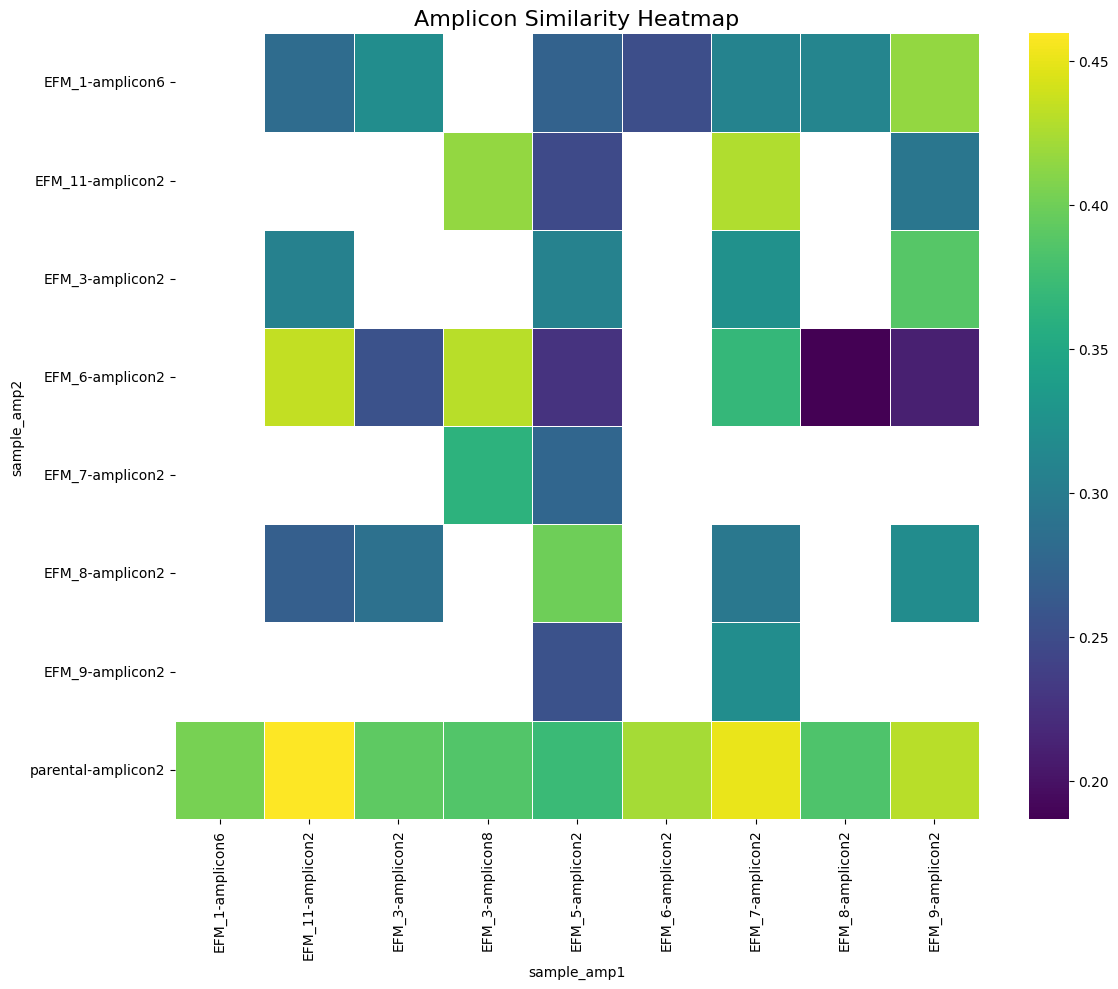

In [76]:
# 1. Pivot table 생성
pivot_df = df_sub.pivot_table(
    index='sample_amp2',      # y-axis
    columns='sample_amp1',    # x-axis
    values='SimilarityScore'
)

# 2. Heatmap 그리기
plt.figure(figsize=(12, 10))

sns.heatmap(
    pivot_df,
    cmap='viridis',   # similarity score에 적합한 colormap
    linewidths=0.5,
    linecolor='white'
)

plt.title('Amplicon Similarity Heatmap', fontsize=16)
plt.xlabel('sample_amp1')
plt.ylabel('sample_amp2')

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

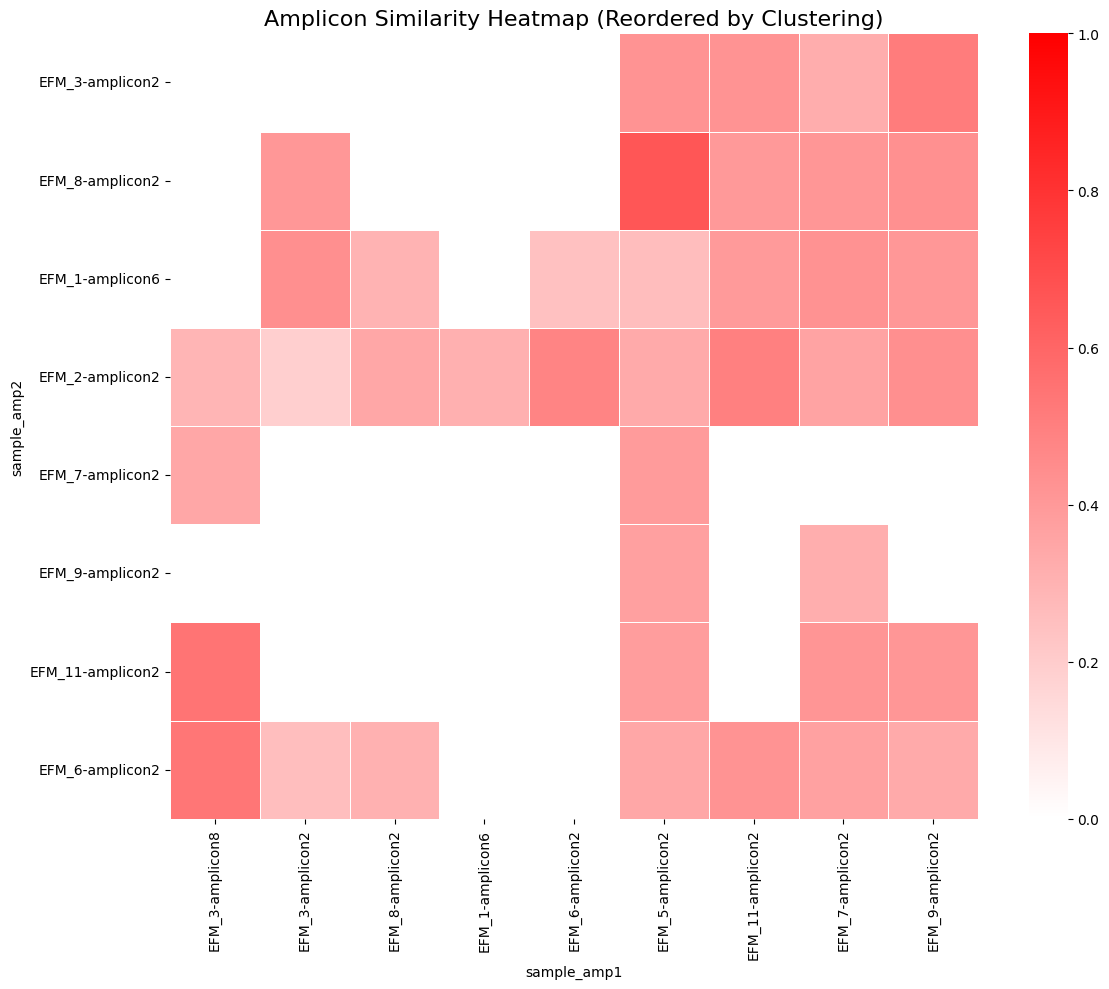

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 1. Pivot table
pivot_df = df_sub.pivot_table(
    index='sample_amp2',
    columns='sample_amp1',
    values='SimilarityScore'
)

pivot_df_filled = pivot_df.fillna(0)

# 2. white -> red colormap
white_red = LinearSegmentedColormap.from_list(
    'white_red',
    ['white', 'red']
)

# 3. clustering으로 순서 추출
cg = sns.clustermap(
    pivot_df_filled,
    cmap=white_red,
    vmin=0, vmax=1,
    method='average',
    metric='euclidean',
    figsize=(12, 10)
)

row_order = cg.dendrogram_row.reordered_ind
col_order = cg.dendrogram_col.reordered_ind
plt.close()

# 4. 재정렬 후 다시 heatmap
pivot_sorted = pivot_df_filled.iloc[row_order, col_order]

plt.figure(figsize=(12, 10))
sns.heatmap(
    pivot_sorted,
    cmap=white_red,
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor='white'
)

plt.title('Amplicon Similarity Heatmap (Reordered by Clustering)', fontsize=16)
plt.xlabel('sample_amp1')
plt.ylabel('sample_amp2')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

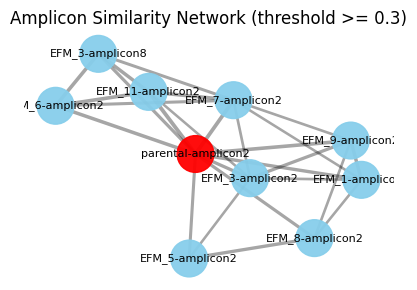

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

threshold = 0.3
df_net = df_sub[df_sub['SimilarityScore'] >= threshold].copy()

G = nx.Graph()

for _, row in df_net.iterrows():
    G.add_edge(
        row['sample_amp1'],
        row['sample_amp2'],
        weight=row['SimilarityScore']
    )

plt.figure(figsize=(4, 3))
pos = nx.spring_layout(G, seed=42, k=0.7)

# 노드 색
node_colors = []
for node in G.nodes():
    if 'parental' in node.lower():
        node_colors.append('red')
    else:
        node_colors.append('skyblue')

# edge 두께
edge_widths = [d['weight'] * 6 for (_, _, d) in G.edges(data=True)]

nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.35)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, alpha=0.95)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title(f"Amplicon Similarity Network (threshold >= {threshold})")
plt.axis("off")
plt.tight_layout()
plt.show()

<ipython-input-79-9198f788d265>:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(groups))


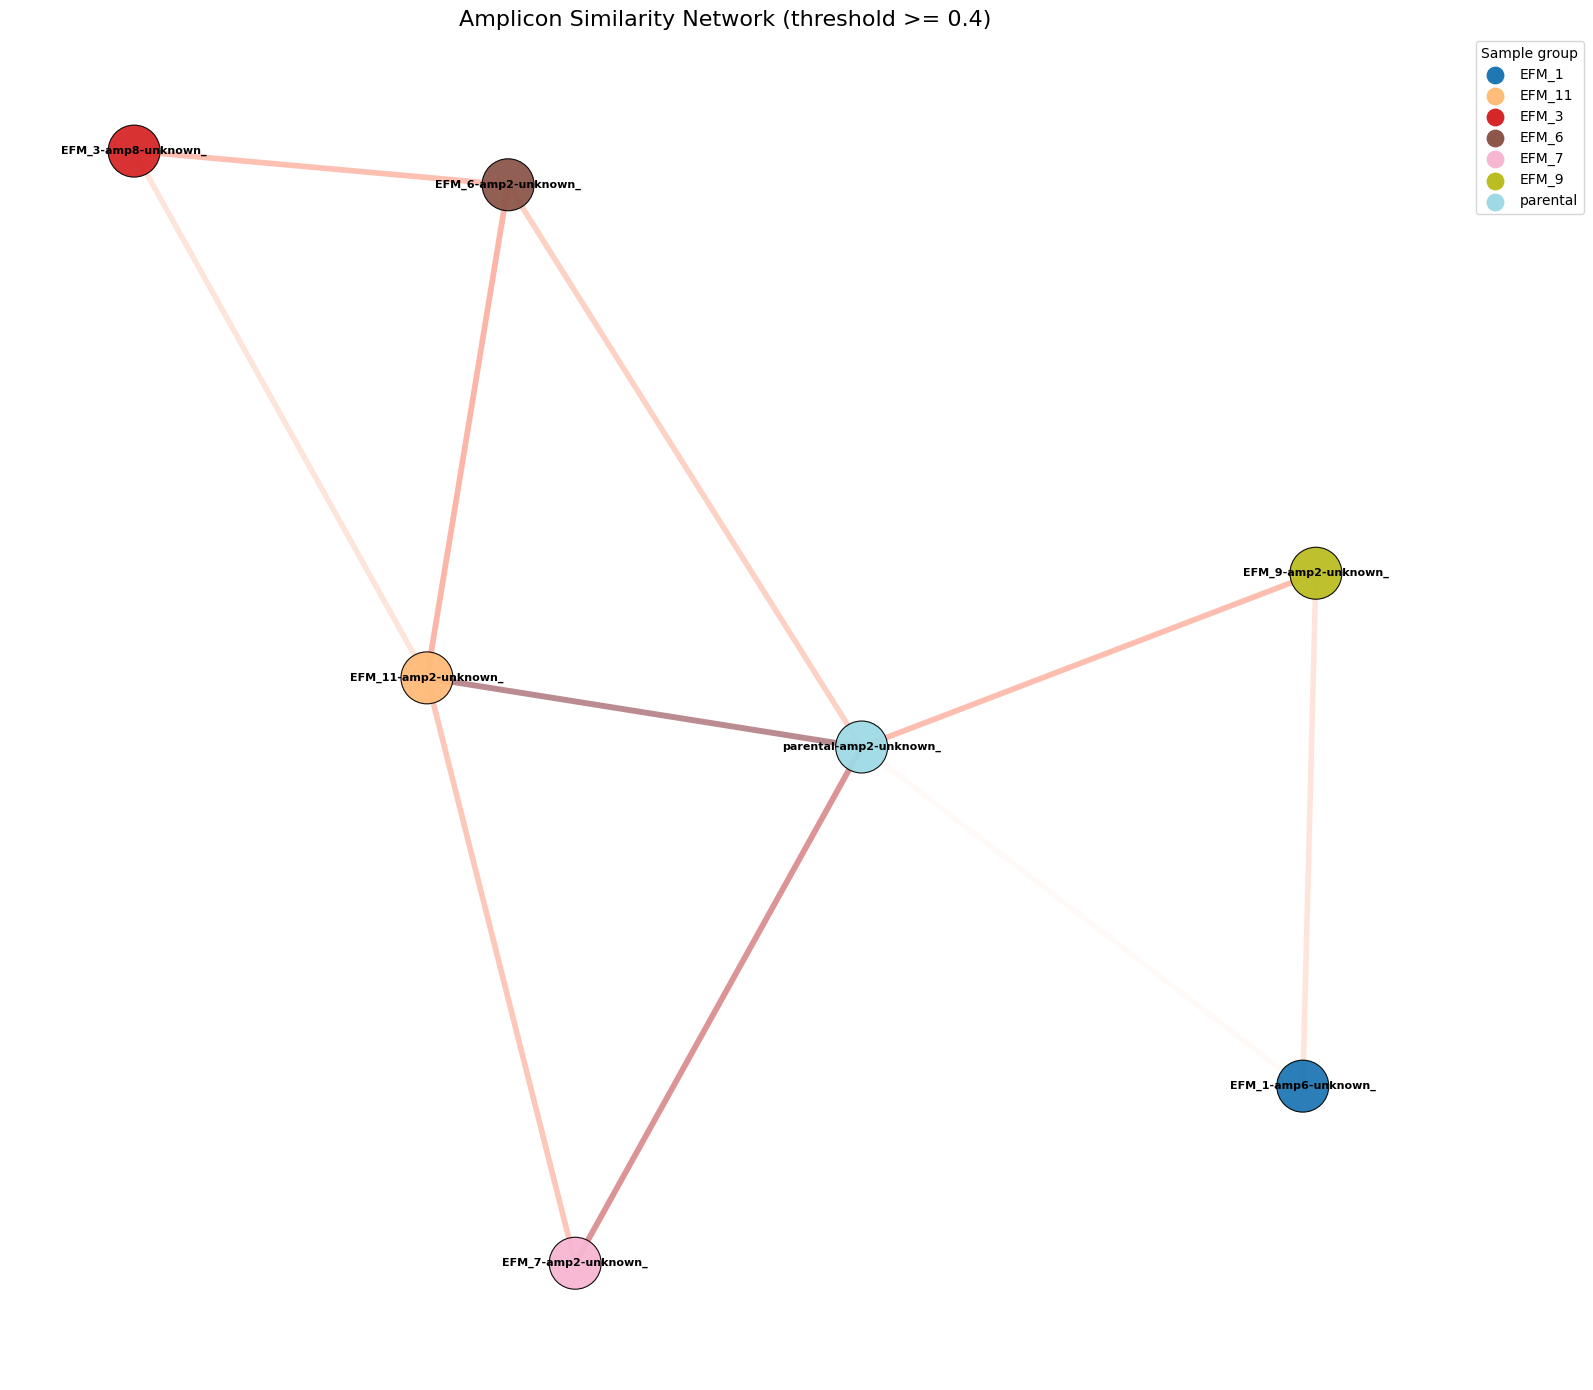

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm
import numpy as np

# -----------------------------
# 1. threshold로 edge 필터링
# -----------------------------
threshold = 0.4
df_net = df_sub[df_sub['SimilarityScore'] >= threshold].copy()

# -----------------------------
# 2. graph 생성
# -----------------------------
G = nx.Graph()

for _, row in df_net.iterrows():
    G.add_edge(
        row['sample_amp1'],
        row['sample_amp2'],
        weight=row['SimilarityScore']
    )

# -----------------------------
# 3. node group / type 파싱 함수
# -----------------------------
def get_group(node):
    # 예: EFM_1-amplicon6-ecDNA_1 -> EFM_1
    #     parental-amplicon2-ecDNA_3 -> parental
    return node.split('-amplicon')[0]

def get_amplicon_type(node):
    # 예: EFM_1-amplicon6-ecDNA_1 -> ecDNA
    #     EFM_2-amplicon4-Complex-non-cyclic_1 -> Complex-non-cyclic
    tail = node.split('-amplicon')[-1]   # "6-ecDNA_1"
    parts = tail.split('-')
    if len(parts) >= 2:
        feature = '-'.join(parts[1:])    # "ecDNA_1" or "Complex-non-cyclic_1"
        feature = feature.rsplit('_', 1)[0]  # "ecDNA" or "Complex-non-cyclic"
        return feature
    return "unknown"

# -----------------------------
# 4. node 색상 설정 (sample group별)
# -----------------------------
groups = sorted({get_group(node) for node in G.nodes()})
cmap = cm.get_cmap('tab20', len(groups))
group_to_color = {g: cmap(i) for i, g in enumerate(groups)}

node_colors = [group_to_color[get_group(node)] for node in G.nodes()]

# -----------------------------
# 5. ecDNA면 테두리 두껍게
# -----------------------------
node_linewidths = []
node_edgecolors = []

for node in G.nodes():
    amp_type = get_amplicon_type(node)
    if amp_type == 'ecDNA':
        node_linewidths.append(2.8)   # 두껍게
        node_edgecolors.append('black')
    else:
        node_linewidths.append(0.8)   # 얇게
        node_edgecolors.append('black')

# -----------------------------
# 6. edge 두께 = similarity score
# -----------------------------
weights = [d['weight'] for (_, _, d) in G.edges(data=True)]
edge_widths = [1.5 + w * 6 for w in weights]

# -----------------------------
# 7. node label 짧게 만들기 (선택)
# -----------------------------
def shorten_label(node):
    group = get_group(node)
    tail = node.split('-amplicon')[-1]   # "6-ecDNA_1"
    amp_num = tail.split('-')[0]         # "6"
    amp_type = get_amplicon_type(node)

    # 마지막 feature index 추출
    if '_' in tail:
        idx = tail.rsplit('_', 1)[-1]
    else:
        idx = ''

    if amp_type == 'Complex-non-cyclic':
        amp_type_short = 'CNC'
    else:
        amp_type_short = amp_type

    return f"{group}-amp{amp_num}-{amp_type_short}_{idx}"

labels = {node: shorten_label(node) for node in G.nodes()}

# -----------------------------
# 8. layout
# k를 줄이면 노드끼리 더 가까워져서 edge가 짧아짐
# iterations를 늘리면 조금 더 안정화됨
# -----------------------------
plt.figure(figsize=(16, 14))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.18,          # 작게 할수록 더 촘촘
    iterations=300
)

# -----------------------------
# 9. drawing
# -----------------------------
nx.draw_networkx_edges(
    G, pos,
    edge_color=weights,
    edge_cmap=plt.cm.Reds,
    edge_vmin=min(weights) if len(weights) > 0 else 0,
    edge_vmax=max(weights) if len(weights) > 0 else 1,
    width=edge_widths,
    alpha=0.45
)

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=1400,          # 노드 크게
    alpha=0.95,
    edgecolors=node_edgecolors,
    linewidths=node_linewidths
)

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=8,
    font_weight='bold'
)

# legend
for g, color in group_to_color.items():
    plt.scatter([], [], c=[color], label=g, s=140)

plt.legend(title="Sample group", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title(f"Amplicon Similarity Network (threshold >= {threshold})", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()
